In [4]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine

# Carichiamo il dataset
wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target

# print(f"Dimensioni del dataset: {df.shape}")
print(f"Classi presenti: {wine.target_names}") # ['class_0', 'class_1', 'class_2']

# Visualizziamo le prime righe
display(df.head())

# Verifichiamo lo sbilanciamento delle classi
print("\nDistribuzione delle classi:")
print(df['target'].value_counts())

Classi presenti: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Distribuzione delle classi:
target
1    71
0    59
2    48
Name: count, dtype: int64


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Caricamento e Scaling
wine = load_wine()
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Conversione in Tensori
# X deve essere float32, y (le classi) deve essere Long per CrossEntropyLoss
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

In [6]:
class WineClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(WineClassifier, self).__init__()
        # Un singolo strato lineare per la regressione logistica multinomiale
        self.linear = nn.Linear(input_dim, output_dim)
        
    def forward(self, x):
        return self.linear(x) # Restituisce i Logits per le 3 classi

model = WineClassifier(input_dim=13, output_dim=3)

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Liste per tracciare il progresso
train_losses = []
test_accuracies = []

# Loss e Ottimizzatore (come visto prima)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100

for epoch in range(epochs):
    # --- FASE 1: TRAINING ---
    model.train() # Attiviamo la modalità training
    optimizer.zero_grad()
    
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    
    # Salviamo la loss di training
    train_losses.append(loss.item())

    # --- FASE 2: VALUTAZIONE (Test Accuracy) ---
    model.eval() # Attiviamo la modalità valutazione
    with torch.no_grad(): # Disabilitiamo il calcolo dei gradienti
        test_outputs = model(X_test_t)
        # Calcolo dell'accuratezza: quanti predetti sono uguali ai reali
        _, predicted = torch.max(test_outputs, 1)
        correct = (predicted == y_test_t).sum().item()
        accuracy = correct / len(y_test_t)
        test_accuracies.append(accuracy)

    if (epoch + 1) % 1 == 0:
        print(f'Epoca [{epoch+1}/{epochs}] | Loss: {loss.item():.4f} | Test Accuracy: {accuracy:.2%}')

Epoca [1/100] | Loss: 0.6548 | Test Accuracy: 94.44%
Epoca [2/100] | Loss: 0.6098 | Test Accuracy: 94.44%
Epoca [3/100] | Loss: 0.5683 | Test Accuracy: 94.44%
Epoca [4/100] | Loss: 0.5302 | Test Accuracy: 94.44%
Epoca [5/100] | Loss: 0.4955 | Test Accuracy: 94.44%
Epoca [6/100] | Loss: 0.4638 | Test Accuracy: 97.22%
Epoca [7/100] | Loss: 0.4351 | Test Accuracy: 97.22%
Epoca [8/100] | Loss: 0.4089 | Test Accuracy: 97.22%
Epoca [9/100] | Loss: 0.3852 | Test Accuracy: 97.22%
Epoca [10/100] | Loss: 0.3637 | Test Accuracy: 97.22%
Epoca [11/100] | Loss: 0.3442 | Test Accuracy: 97.22%
Epoca [12/100] | Loss: 0.3265 | Test Accuracy: 97.22%
Epoca [13/100] | Loss: 0.3103 | Test Accuracy: 97.22%
Epoca [14/100] | Loss: 0.2956 | Test Accuracy: 97.22%
Epoca [15/100] | Loss: 0.2822 | Test Accuracy: 97.22%
Epoca [16/100] | Loss: 0.2699 | Test Accuracy: 97.22%
Epoca [17/100] | Loss: 0.2586 | Test Accuracy: 97.22%
Epoca [18/100] | Loss: 0.2483 | Test Accuracy: 97.22%
Epoca [19/100] | Loss: 0.2388 | Test 

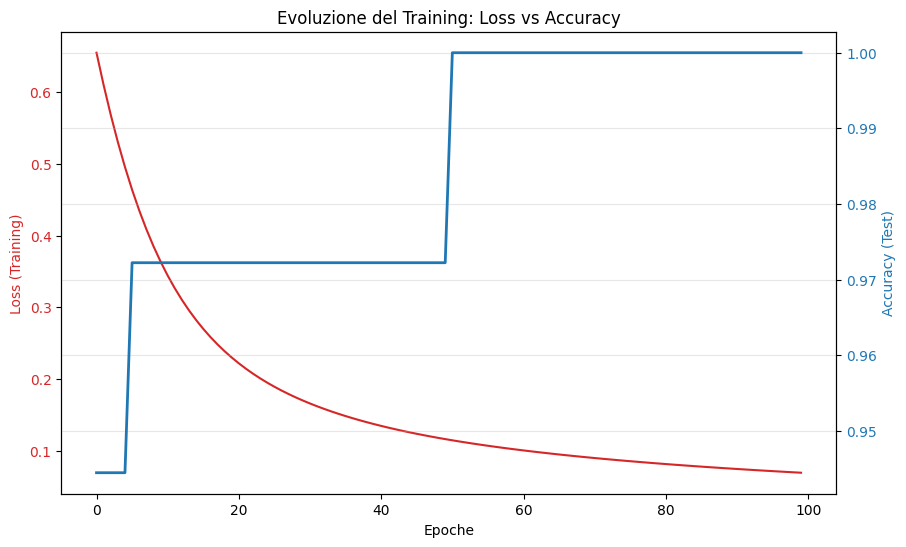

In [10]:
# Creazione del grafico con due assi
fig, ax1 = plt.subplots(figsize=(10, 6))

# Grafico della Loss (asse sinistro)
ax1.set_xlabel('Epoche')
ax1.set_ylabel('Loss (Training)', color='tab:red')
ax1.plot(train_losses, color='tab:red', label='Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Grafico dell'Accuracy (asse destro)
ax2 = ax1.twinx() 
ax2.set_ylabel('Accuracy (Test)', color='tab:blue')
ax2.plot(test_accuracies, color='tab:blue', label='Test Accuracy', lw=2)
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Evoluzione del Training: Loss vs Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

Il modello raggiunge un'ottima accuracy perchè il dataset è molto semplice. Proviamo ad aggiungere del "rumore" e vediamo come si comporta

In [13]:
import numpy as np

# Carichiamo i dati originali
X_orig, y = wine.data, wine.target

# --- SFIDA: AGGIUNGIAMO IL RUMORE ---
# Più alto è il noise_factor, più i dati saranno "sporchi"
noise_factor = 1.0
noise = np.random.normal(0, noise_factor, X_orig.shape)
X_noisy = X_orig + noise

# Split e Scaling dei dati rumorosi
X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Conversione in Tensori
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)


In [14]:
model_noisy = WineClassifier(13, 3)
optimizer = optim.Adam(model_noisy.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(200):
    model_noisy.train()
    optimizer.zero_grad()
    outputs = model_noisy(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

# Valutazione finale
model_noisy.eval()
with torch.no_grad():
    logits = model_noisy(X_test_t)
    preds = torch.argmax(logits, dim=1)
    acc = (preds == y_test_t).sum().item() / len(y_test_t)

print(f"Accuratezza con rumore (factor {noise_factor}): {acc:.2%}")

Accuratezza con rumore (factor 1.0): 94.44%


1. Scomparsa del 100%: Con un noise_factor sufficientemente alto, alcune bottiglie di vino di classi diverse "sembreranno" chimicamente identiche. Il modello non potrà più distinguerle perfettamente perché le informazioni originali sono state parzialmente coperte dal rumore.

2. Robustezza: Un modello "robusto" è quello che mantiene un'accuratezza accettabile (es. 90-95%) anche quando i dati sono sporchi. Se l'accuratezza crollasse al 50%, significherebbe che il modello non ha imparato le caratteristiche reali ma si era solo "appoggiato" a dettagli fragili del dataset pulito.

3. Visualizzazione del Confine: Se potessimo vedere la Decision Boundary ora, non vedremmo più una linea che divide perfettamente i punti, ma vedremmo molti punti "dalla parte sbagliata" del confine.

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

# Supponiamo di avere y_test e y_pred dal modello PyTorch precedente
target_names = ['Barolo', 'Grignolino', 'Barbera'] # I nomi reali del Wine Dataset

print("Confusion matrix")
display(confusion_matrix(y_test, preds))

print()
print("Classification_report")
report = classification_report(y_test, preds, target_names=target_names)
print(report)

Confusion matrix


array([[13,  1,  0],
       [ 0, 14,  0],
       [ 0,  1,  7]])


Classification_report
              precision    recall  f1-score   support

      Barolo       1.00      0.93      0.96        14
  Grignolino       0.88      1.00      0.93        14
     Barbera       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

